# Section 1: Loading & Shuffle Dataset

* Summary of section 1:
  * Write a function for loading data so that we can reuse the function to load training, validation and testing dataset
  * Load the data using function written earlier
  * Check the shape of the dataset
  * Shuffle the training and validation dataset by using numpy.random.permutation.

In [ ]:
# Loading data function
def load_data(pickle_file):
  import pickle
  with open(pickle_file,"rb") as f:
    dict=pickle.load(f)
  return dict[b"data"],dict[b"labels"],dict[b"class_names"]


In [4]:
# Load the data
X_train,y_train,class_names = load_data("./train-2025.pkl")
X_valid,y_valid,_ = load_data("./valid-2025.pkl")
X_test,y_test,_ = load_data("./test-2025.pkl")

In [5]:
# Check the shape of the dataset
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (4200, 64, 64, 3), y_train shape: (4200,)
X_valid shape: (1200, 64, 64, 3), y_valid shape: (1200,)
X_test shape: (600, 64, 64, 3), y_test shape: (600,)


In [6]:
# Shuffle training and validation set based on the index
import numpy as np

np.random.seed(42) # Set the seed for training indices

train_indices= np.random.permutation(X_train.shape[0])
valid_indices= np.random.permutation(X_valid.shape[0])

In [7]:
# Shuffled training and validation set
X_train_shuffle,y_train_shuffle = X_train[train_indices],y_train[train_indices]
X_valid_shuffle,y_valid_shuffle = X_valid[valid_indices],y_valid[valid_indices]


# Section 2: Function display images

* Summary of section 2:
  * Write the display_images function that can use to display images for training, validation and testing dataset
  * Display images for training, validation and testing data using function written earlier
  * The display_images is added with "display_idx" parameter to handle the requirement in Comparisons section

In [8]:
import matplotlib.pyplot as plt

# Define function for plotting images
# display_idx parameter is used in Comparisons section
# Set default number of images to display as 30, random seed as None
def display_images(X,y,class_name,plot_title,num_images=30,rand_seed =None, display_idx=None):

  # If random seed set by user, then set the random seet
  if rand_seed is not None:
    np.random.seed(rand_seed)
  # If the display index is given, then display the images based on the index
  if display_idx is None:
    # Randomly select the index with number of images declared by user
    display_idx = np.random.choice(X.shape[0],size=num_images, replace=False)

  plt.figure(figsize=(15,8))

  for i,idx in enumerate(display_idx[:num_images]):
    plt.subplot(6,10,i+1) # Set the subplot. Maximum 60 images with 10 images for each row
    plt.imshow(X[idx])
    plt.title(class_name[y[idx]])
    plt.axis("off")

  # Show the title
  plt.suptitle(plot_title,fontsize=15)
  plt.tight_layout()
  plt.show()





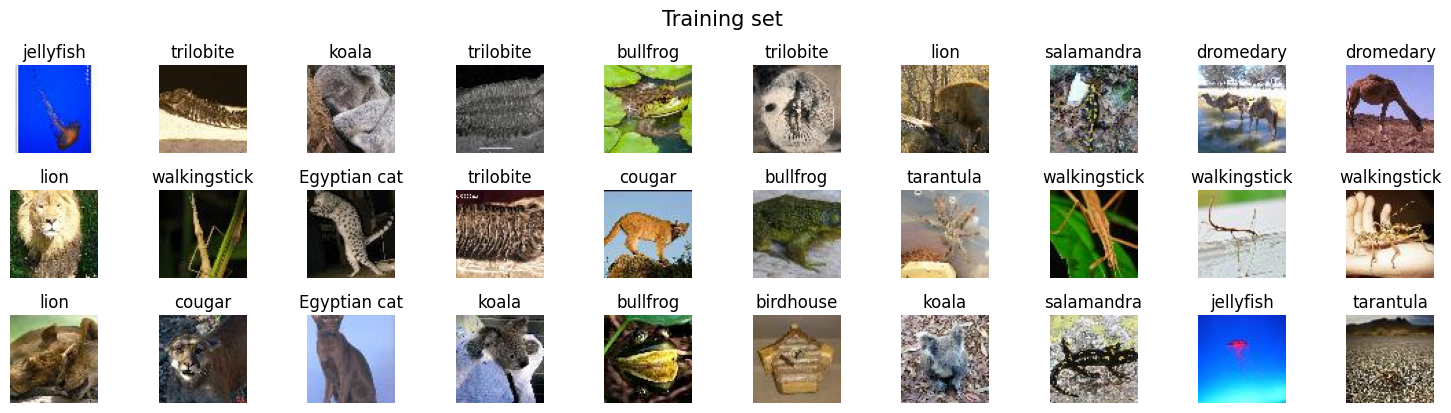

In [9]:
# Display the images for trianing set
display_images(X_train_shuffle,y_train_shuffle,class_names,plot_title="Training set",num_images=30)

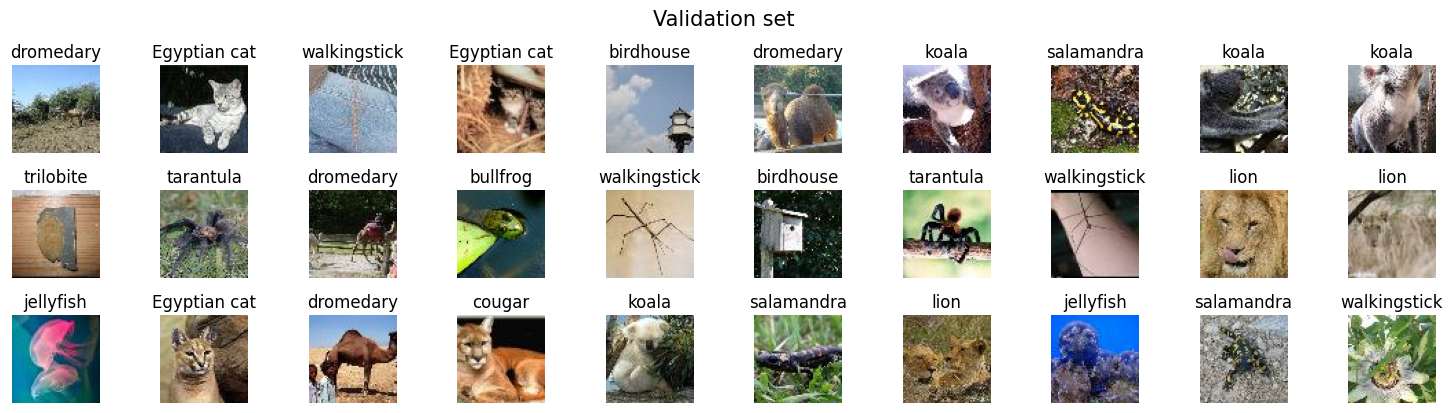

In [10]:
# Display the images for validation set
display_images(X_valid_shuffle,y_valid_shuffle,class_names,plot_title="Validation set",num_images=30)

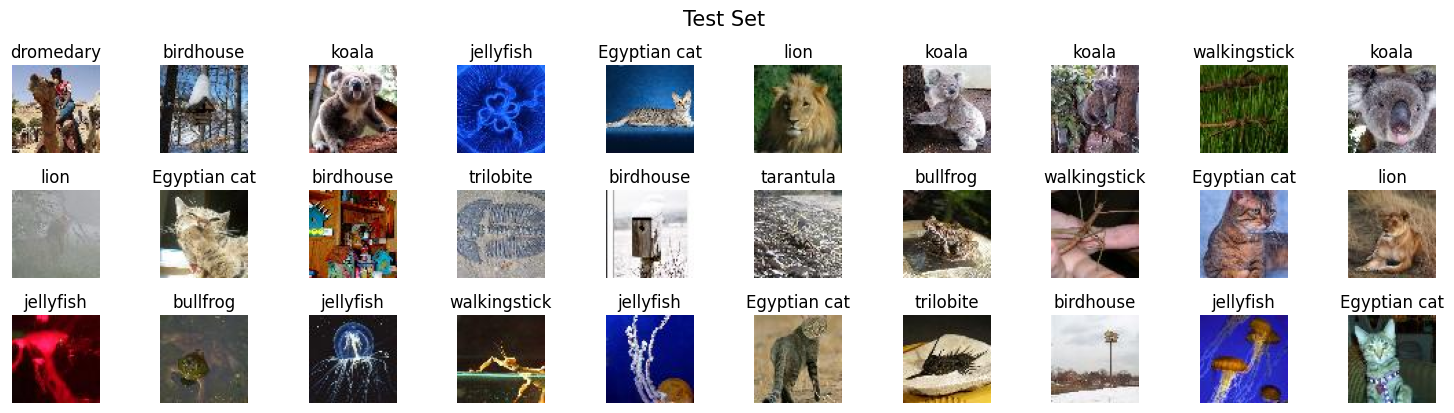

In [11]:
# Display the images for test set
display_images(X_test,y_test,class_names,plot_title="Test Set",num_images=30)

# Section 3: Implementation and hyperparameter tuning of a CNN model

* Summary of section 3:
  * Set up the exponential decay learning rate scheduler and early stopping callbacks for both hyperparameter tuning and re-train pre-trained MobileNetV3Small model 
  * Implement the hyperparameter tuning logic
  * Set up the model which consists of 4 convolutional layers, 4 max pooling layers, 2 batch normalization layers, 1 global average pooling layer, 1 dropout layer, 1 dense layer, and 1 output layer. Use Adam as optimizer, and exponential decay function on learning rate scheduler.
    * Set output layer with 12 neurons as we have 12 classes to classify.
  * Use BayesianOptimization from keras_tuner to tune the number of filters in each of the 4 convolutional layers, drop out rate, and number of neurons in the dense layer.
  * When set the range of hyperparameter, set the combination of the maximum of this hyperparameter in a way that total trainable parameter is below 30,000.
  * Use a for loop to let the tuner to run 4 times by default and stop the tuner search once a model with 50% accuracy is found.
  * Record the best model, hyperparameter, accuracy, loss, time taken for each search, total time taken to search the model with at least 50% accuracy. We will store these values in corresponding Python lists.
  * Save the desired model & show the summary of the CNN architecture model
  * If the hyperparameter tuning indicator set as False, then load the saved model and show the summary of the CNN architecture model.



In [ ]:
# Uncomment to install keras tuner if needed
# !pip install -q keras_tuner 

# Library for setting up model and callbacks
import tensorflow as tf
from tensorflow.keras import layers, models,optimizers,Model
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping

# Library for hyperparameter tuning
import keras_tuner as kt
import time # For tracking the tuning and training time


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.9 MB/s eta 0:00:00


In [13]:
# Set up the Early Stopping and Exponential Decay Learning Rate Scheduler for self trained CNN and pre-trained MobileNetV3Small

# Define exponential decay function for learning rate scheduler
def exponential_decay(lr0,s):
  def exponential_decay_fn(epoch):
    return lr0 * 0.1**(epoch/s)
  return exponential_decay_fn

# Set up exponential decay function, using initial learning rate = 0.01 and step size = 20
exponential_decay_fn = exponential_decay(lr0=0.01,s=20)

# Set up callbacks for learning rate scheduler and early stopping
lr_scheduler_exp_decay = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
early_stopping_cb = EarlyStopping(patience=10, restore_best_weights=True) # Use patience=10 for early stopping


In [ ]:
# Logic implementation for hyperparameter tuning

# Set to TRUE if would like to proceed for hyperparamter
hyperparameter_tuning = False

if hyperparameter_tuning == True:

  # Define the CNN model architecture
  def cnn_model(hyper_param):

    # Set the hyperparameter for tuning

    # 4 layers of filters for tuning
    convo_fil_1 = hyper_param.Int("filter_1",min_value=8,max_value=12)
    convo_fil_2 = hyper_param.Int("filter_2",min_value=13,max_value=16)
    convo_fil_3 = hyper_param.Int("filter_3",min_value=17,max_value=32)
    convo_fil_4 = hyper_param.Int("filter_4",min_value=33,max_value=64)

    # Drop out rate for tuning
    drp_out_rate = hyper_param.Float("drp_out_rate",min_value=0.1,max_value=0.5)

    # Number of neurons
    n_neurons = hyper_param.Int("n_neurons", min_value=30,max_value=50)

    # Set the default convolutional layers for reusing at layer stage
    DefaultConv2D = partial(layers.Conv2D,kernel_size=3 ,activation='relu', kernel_initializer="he_normal")
    DefaultMaxPool2D = partial(layers.MaxPooling2D,pool_size=(2,2))

    # Use Adam for the optimizer
    optimizer = optimizers.Adam()

    # Create the sequential model
    model= models.Sequential([

        # Input layers
        layers.Input(shape=[64,64,3]),

        # First convolutional layers + Batch Normalization + Max Pooling
        DefaultConv2D(filters = convo_fil_1,kernel_size=5),
        layers.BatchNormalization(),
        DefaultMaxPool2D(),

        # Second convolutional layers + Max Pooling
        DefaultConv2D(filters = convo_fil_2),
        DefaultMaxPool2D(),

        # Third convolutional layers + Batch Normalization + Max Pooling
        DefaultConv2D(filters = convo_fil_3),
        layers.BatchNormalization(),
        DefaultMaxPool2D(),

        # Fourth convolutional layers + Max Pooling
        DefaultConv2D(filters = convo_fil_4),
        DefaultMaxPool2D(),

        # Global Average Pooing layer
        layers.GlobalAveragePooling2D(),

        # Drop out layer
        layers.Dropout(drp_out_rate),

        # Dense layer with relu as activation function
        layers.Dense(n_neurons,activation="relu"),

        # Output layer with 12 neurons (12 classes)
        # Use softmax as activation function for multiclassification task
        layers.Dense(12,activation="softmax")])

    # Compile the model
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])

    return model


  # Try to run the optimizer search 4 times
  # You should obtain at least one model with more than 50% accuracy within 4 trials
  optimizers_trial=4

  # Initialize list to store the models, loss, accuracy and model's hyperparamter
  best_loss_list=[]
  best_accuracy_list =[]
  best_model_list = []
  best_hp_param_list = []
  model_time_list = []


  for i in range(optimizers_trial):

    # Break loop if the best_accuracy_list is not empty and one of the model achieve > 50%
    if best_accuracy_list != [] and max(best_accuracy_list)>0.5:
      print(f"\n Stopping search early: Model with accuracy = {max(best_accuracy_list):.3f} is found.\n")
      break

    else:

      print(f"\n ===== Run of optimizer: {i+1} of {optimizers_trial} ===== \n")

      # Track start time of the tuner
      start_time_tuner = time.time()

      # Set up Bayesian Optimization tuner with max trials = 10
      bayesian_opt_tuner = kt.BayesianOptimization(cnn_model, objective="val_accuracy",max_trials=10, alpha=1e-4, beta=2.6,overwrite=True, directory="my_cnn", project_name=f"bayesian_opt_{i}")

      # Start the search with 100 epochs for each search
      # Early stopping and exponential decay learning rate scheduler set in callbacks
      bayesian_opt_tuner.search(X_train_shuffle, y_train_shuffle, epochs=100,validation_data=(X_valid_shuffle, y_valid_shuffle),callbacks=[early_stopping_cb,lr_scheduler_exp_decay])

      # Track end time for each tuner
      end_time_tuner = time.time()

      # Get the found model from the tuner
      best_model = bayesian_opt_tuner.get_best_models(num_models=1)[0]

      # Get the test loss and test accuracy from the found model
      test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

      # Get the hyperparameters from the found model
      best_model_hp = bayesian_opt_tuner.get_best_hyperparameters(num_trials=1)

      # Append the results to the respective list
      best_loss_list.append(test_loss) # Track loss value for best model found by tuner
      best_accuracy_list.append(test_accuracy) # Track accuracy for best model found by tuner
      best_model_list.append(best_model) # Store best model found by tuner
      best_hp_param_list.append(best_model_hp[0].values) # Store hyperparameter for best model found by tuner

      # Track the total time for each run of the tuner
      model_time_list.append(end_time_tuner-start_time_tuner)

  # Get the best accuracy for each run of the tuner
  best_accuracy_model = max(best_accuracy_list)

  # Get the index of the best accuracy
  best_accuracy_index = best_accuracy_list.index(best_accuracy_model)

  # Get the best model found from the model listing
  best_cnn_model = best_model_list[best_accuracy_index]

  # Get the hyperparamter of the best model found
  best_hp_param = best_hp_param_list[best_accuracy_index]

  # Get the tuning time for that particular best model found
  tune_model_time = model_time_list[best_accuracy_index]

  # Get the total time to find the best model (Total tuner time)
  total_time_tuner = sum(model_time_list)

  # Print the results
  print(f"\n The best hyperparameter for the found model:{best_hp_param} \n")

  print(f"\n The best accuracy for the found model: {best_accuracy_model:.4f}")

  print(f"\n The time taken to tune the found CNN model is {tune_model_time:.3f} seconds or {tune_model_time/60:.3f} minutes")

  print(f"\n Total time to get the found CNN model is {total_time_tuner/60:.3f} minutes. \n")

  # Save the best model found
  best_cnn_model.save("Yap_LiangKooi-CNN.keras")

  # Show the summary of the best model found
  best_cnn_model.summary()

else:
    # Load model the previously saved model
    best_cnn_model = tf.keras.models.load_model("Yap_LiangKooi-CNN.keras")

    # Show the summary of the loaded model
    best_cnn_model.summary()




Trial 10 Complete [00h 00m 29s]
val_accuracy: 0.4933333396911621

Best val_accuracy So Far: 0.5274999737739563
Total elapsed time: 00h 05m 25s
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4770 - loss: 1.5997

 The best hyperparameter for the found model:{'filter_1': 12, 'filter_2': 14, 'filter_3': 29, 'filter_4': 60, 'drp_out_rate': 0.14323437748338874, 'n_neurons': 38} 


 The best accuracy for the found model: 0.5233

 The time taken to tune the found CNN model is 324.908 seconds or 5.415 minutes

 Total time to get the found CNN model is 22.165 minutes. 



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 12)     │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 14)     │         1,526 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 14)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 29)     │         3,683 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 29)     │           116 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 29)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 60)       │        15,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 60)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │         2,318 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           468 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,791 (96.84 KB)

 Trainable params: 24,709 (96.52 KB)

 Non-trainable params: 82 (328.00 B)

# Section 4: Transfer learning using MobileNetV3Small

* Strategy to re-train MobileNetV3Small to get better result
  * Input size with (64,64,3) was used to train the model and the accuracy achieved is between 60-65%.
  * To achieve a higher accuracy than this, the input size is resize to (224,224,3).
  * This is because original imagenet model was trained using the size of (224,224,3).
  * The steps to resize of input layers and using pre-trained model is shown in the summary below.

* Summary for section 4:
  * Initialize a Input layer
  * Resize the input layer and pass this layer to the original MobileNetV3Small (exclude top layers).
  * Load the MobileNetV3Small model. Set the include_top parameter=False by exclude the top layers in the original model and keep the weights by setting weights = "imagenet".
  * Add in Global Average Pooling layer, Dense layer with 30 neurons and "relu" activation function, and Output layer with 12 neurons (12 classes of a multiclassification task) and Softmax as activation functions.
    * Use Softmax activation function to get probability of each classes. Highest probability of a class is the predicted class. Sum of all classes probabilities of a instance will be equal to 1.
  * Freeze the all layers before the last 3 added layers. This will train the added dense layers and output layers. This largely reduce the trainable parameter.
  * Compile the model and show the top 4 layers and botton 4 layers.
    * Note: Since we add Input & Resize layers before the pre-trained model layer, the pretrained model layer will be considered as one layer when show in summary function. We can expand the MobileNetV3Small model by using the parameter expand_nested = True.
  * Train the compiled model by using the same learning rate scheduler and early stopping. At the same time, keep track of the training time.
  * Display the learning curves of training & validation loss vs epoch, and training & validation accuracy vs epoch.

* Comment on learning curves:
  * It is noticed that training accuracy is way higher than validation accuracy
  * The training loss is way lower than validation loss
  * Both the learning curves indicates that the model is overfitting.
  * Various ways can reduce the overfitting problem such as add in dropout layer, batch normalization layer before the output layer. We can also reduce the number of neurons in the dense layer. 
  


In [ ]:
# Pretrained model - MobileNetV3Small

# Get the pre-trained model
from tensorflow.keras.applications import MobileNetV3Small

# Set up the input layers with the size of the X
input_layer = layers.Input(shape=(64,64,3))

# Resize the input layers to (224,224,3)
# Resize image to obtain a better accuracy around 85-88%
# This is due to pre-trained model is trained using this shape.
# If we use the same input shape, a accuracy is achieved around 60-65%
resize_input_layer = layers.Resizing(224,224)(input_layer)

# Load the model with input shape of (224,224,3) and exclude the top part of the model
# Keep the weights in the pre-trained model by setting weights = "imagenet"
load_mobilenet_mod = MobileNetV3Small(input_shape=[224,224,3],include_top=False,weights="imagenet")

# Pass through the resize input layer to the MobileNetV3Small model
base_model = load_mobilenet_mod(resize_input_layer)

# Set up the Global Average Pooling layer, dense layer and output layers
global_avg_layer = layers.GlobalAveragePooling2D()(base_model)
dense_layer_last = layers.Dense(30,activation="relu")(global_avg_layer) # Tune the neurons if not satisfy with the result
output_layer = layers.Dense(12,activation="softmax")(dense_layer_last) # 12 neurons as we have 12 classes

# Set up the final pre-trained model
final_pretrain_model = Model(input_layer,output_layer)

# Freeze the layers before last 3 layers
for layer in final_pretrain_model.layers[:-3]:
  layer.trainable=False

# Compile model
final_pretrain_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam",metrics=["accuracy"])

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# First 4 layers of the model
final_pretrain_model.summary(layer_range=(final_pretrain_model.layers[0].name,final_pretrain_model.layers[3].name))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,802 (3.65 MB)

 Trainable params: 17,682 (69.07 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [17]:
# Last 4 layers of the model
final_pretrain_model.summary(layer_range=(final_pretrain_model.layers[-4].name,final_pretrain_model.layers[-1].name))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │        17,310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,802 (3.65 MB)

 Trainable params: 17,682 (69.07 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [18]:
# Track the start time of the pretrain model
start_time_pretrain = time.time()

# Fit the model with early stopping and exponential decay learning scheduler
history_pretrain_model = final_pretrain_model.fit(X_train_shuffle,y_train_shuffle,epochs=200,validation_data=(X_valid_shuffle,y_valid_shuffle),callbacks=[early_stopping_cb,lr_scheduler_exp_decay])

# Track end time of the pre-train model
end_time_pretrain = time.time()

Epoch 1/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 29s 136ms/step - accuracy: 0.6209 - loss: 1.2084 - val_accuracy: 0.8250 - val_loss: 0.5276 - learning_rate: 0.0100
Epoch 2/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8734 - loss: 0.3920 - val_accuracy: 0.8683 - val_loss: 0.4165 - learning_rate: 0.0089
Epoch 3/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8895 - loss: 0.3160 - val_accuracy: 0.8742 - val_loss: 0.4092 - learning_rate: 0.0079
Epoch 4/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9207 - loss: 0.2242 - val_accuracy: 0.8758 - val_loss: 0.3817 - learning_rate: 0.0071
Epoch 5/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9404 - loss: 0.1817 - val_accuracy: 0.8700 - val_loss: 0.4295 - learning_rate: 0.0063
Epoch 6/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9466 - loss: 0.1536 - val_accuracy: 0.8717 - val_loss: 0.4323 - learning_rate: 0.0056
Epoch 7/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9662 -

In [19]:
# Show the total training time for the pre-trained model

total_time_pretrain = end_time_pretrain-start_time_pretrain
print(f"Total time to re-train the pre-trained model is {total_time_pretrain:.3f} seconds or {total_time_pretrain/60:.3f} minutes")


Total time to re-train the pre-trained model is 49.250 seconds or 0.821 minutes


In [20]:
loss_pretrain, accuracy_pretrain =final_pretrain_model.evaluate(X_test,y_test)

print(f"Accuracy for the pre-train model is {accuracy_pretrain:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.8647 - loss: 0.3991
Accuracy for the pre-train model is 0.8717


Comment on learning curves

* The training accuracy is way too higher than validation accuracy.
* The training loss is way too lower than validation loss. 
* These are the indicator that the model is overfitting.
* We can try to set lower number of neurons in the dense layer or add batch normalization layers before the output layer. We can also add in dropout layer before the output layer to reduce the overfitting issue. 

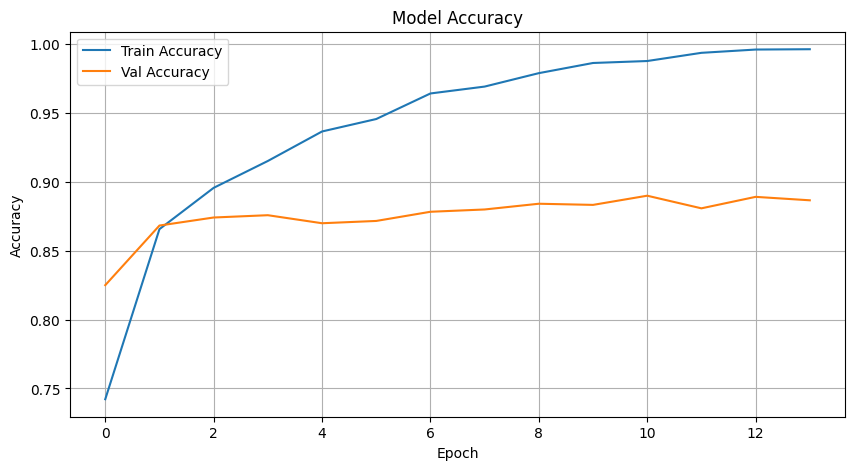

In [21]:
# Plot training & validation accuracy
plt.figure(figsize=(10,5))
plt.plot(history_pretrain_model.history['accuracy'], label='Train Accuracy')
plt.plot(history_pretrain_model.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


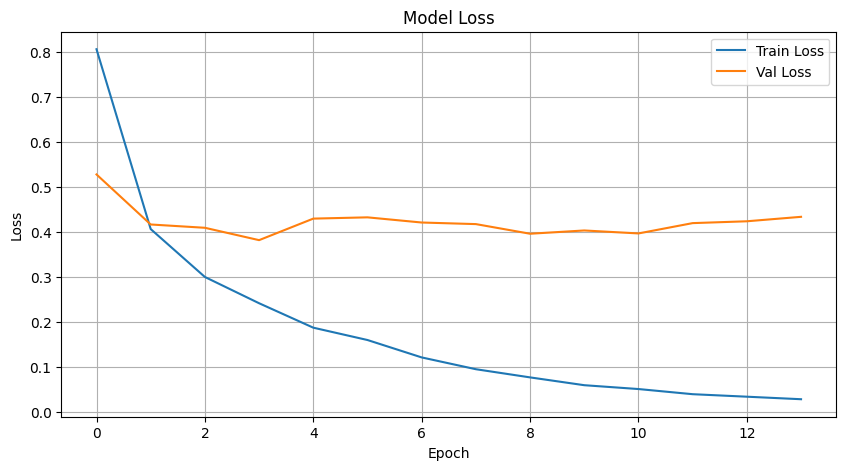

In [22]:
# Plot training & validation loss
plt.figure(figsize=(10,5))
plt.plot(history_pretrain_model.history['loss'], label='Train Loss')
plt.plot(history_pretrain_model.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Use similar method in hyperparameter tuning
# To avoid overwrite the existing saved model
# Save the re-train pre-trained model

# Save model indicator
# Set the indicator to False so that the existing model will not be overwrite
save_model_indicator = False

# Save the model if we want to retrain and save it again
if save_model_indicator == True:
  final_pretrain_model.save("Yap_LiangKooi-MobileNetv3.keras")


# Section 5: Comparisons between CNN model & retrained MobileNetV3Small

## 5.1 Reload both models from Keras files

In [ ]:
# Reload both models
my_cnn_model = tf.keras.models.load_model("Yap_LiangKooi-CNN.keras")
my_mobilenet_model = tf.keras.models.load_model("Yap_LiangKooi-MobileNetv3.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 5.2 Time taken to tune hyperparameters and train MobileNetV3Small model and complexity comparisons

Comparison table as below:

| Model | Time taken to train / tune | Model complexity |
| ----- | ----- | -----|
| CNN Model | Approximate 5 to 6 minutes to tune hyperparameter | Total trainable parameter = 24,709|
| MobineNetV3Small | Approximate 1 minute to train model | Total trainable parameter = 17,682 |

* Note: For running several times on the tuner to search the best model, total taken is 22 - 23 minutes to find the best model



* From the table above:
   * It is observed that the time taken to train it takes about 6 minutes to tune the hyperparameter and obtain the model with at least 50% accuracy. The obtained CNN model has parameter around 24,709. It took about 4 search to obtain the best model. Hence the total time taken for the search is approximate 22-23 minutes.
  * While the pre-trained model, it has lesser trainable parameter which is rougly about 17,682. It is noticeable that it took less than a minute to train the model with the implementation of early stopping

## 5.3 Model performance of both models

* Summary for section 5.3:
  1. Obtain the prediction value from both models
  2. Use the classification report in the Scikit-Learn library to show the performance of both models such as precision, recall, F1 score and accuracy

* Performance for both models:
  1. Detailed performance can be checked in the classification report table below
  2. Summary of the both models performance as below:
    * CNN model achieve accuracy around 52.3% while pre-trained model accuracy is around 87.2%.
    * Birdhouse and cougar has lowest F1 score in CNN model compared to other class which is 36% and 29.9%. However, pre-trained model has far better F1 score which is roughly around 88.9% and 74.8% respectively.
    * Salamandra and jellyfish has the F1 score around 80.8% and 75.5% respectively in CNN model. Again, pre-trained model has higher F1 score 92.6% and 96.0% compared to CNN model.
  

In [25]:
# Prediction value for CNN model
y_proba_cnn = my_cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_proba_cnn,axis=1)

# Prediction value for MobileNetV3Small
y_proba_mobilenet =  my_mobilenet_model.predict(X_test)
y_pred_mobilenet = np.argmax(y_proba_mobilenet,axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step


In [ ]:
from sklearn.metrics import classification_report

# Print the classification report for CNN model
print("\n Classification report for my CNN model: \n")
print(classification_report(y_test,y_pred_cnn,target_names=class_names,digits=3))


 Classification report for my CNN model: 

              precision    recall  f1-score   support

Egyptian cat      0.407     0.440     0.423        50
   birdhouse      0.410     0.320     0.360        50
    bullfrog      0.585     0.620     0.602        50
      cougar      0.351     0.260     0.299        50
   dromedary      0.511     0.460     0.484        50
   jellyfish      0.714     0.800     0.755        50
       koala      0.583     0.560     0.571        50
        lion      0.347     0.520     0.416        50
  salamandra      0.778     0.840     0.808        50
   tarantula      0.548     0.460     0.500        50
   trilobite      0.542     0.520     0.531        50
walkingstick      0.490     0.480     0.485        50

    accuracy                          0.523       600
   macro avg      0.522     0.523     0.519       600
weighted avg      0.522     0.523     0.519       600



In [ ]:
# Print the classification report for MobileNetV3Small model
print("\n Classification report for MobileNetV3Small model: \n")
print(classification_report(y_test,y_pred_mobilenet,target_names=class_names,digits=3))


 Classification report for MobileNetV3Small model: 

              precision    recall  f1-score   support

Egyptian cat      0.849     0.900     0.874        50
   birdhouse      0.898     0.880     0.889        50
    bullfrog      0.927     0.760     0.835        50
      cougar      0.702     0.800     0.748        50
   dromedary      0.885     0.920     0.902        50
   jellyfish      0.960     0.960     0.960        50
       koala      0.857     0.840     0.848        50
        lion      0.788     0.820     0.804        50
  salamandra      0.978     0.880     0.926        50
   tarantula      0.840     0.840     0.840        50
   trilobite      0.979     0.940     0.959        50
walkingstick      0.852     0.920     0.885        50

    accuracy                          0.872       600
   macro avg      0.876     0.872     0.872       600
weighted avg      0.876     0.872     0.872       600



## 5.4 Confusion Matrix for both models

* Summary of section 5.4:
  * Import related library from Scikit-Learn such as confusion matrix and ConfusionMatrixDisplay
  * Write a simple function to display confusion matrix that can be reused for both model
  * Display the confusion matrix for both models

* Highlight of confusion matrix for both models:
  1. CNN Model:
    * Salamandra(42/50) and jellyfish(40/50) has the highest number that got correct classification
    * Cougar has only classified 13 correctly. It has wrongly classify 14 of the instances as lion. As some of the lions images has high similarity image properties to cougar.
  2. MobileNetV3Small model:
    * Dromedary, jellyfish, trilobite, and walking stick are has almost classify correctly.

In [28]:
# Import library
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [29]:
# Define function for confusion matrix
def disp_confusion_matrix(y_test,y_pred,cls_name,plot_title):
  cm = confusion_matrix(y_test,y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  disp.plot(cmap="Blues",xticks_rotation=90)
  plt.title(plot_title)
  plt.show()


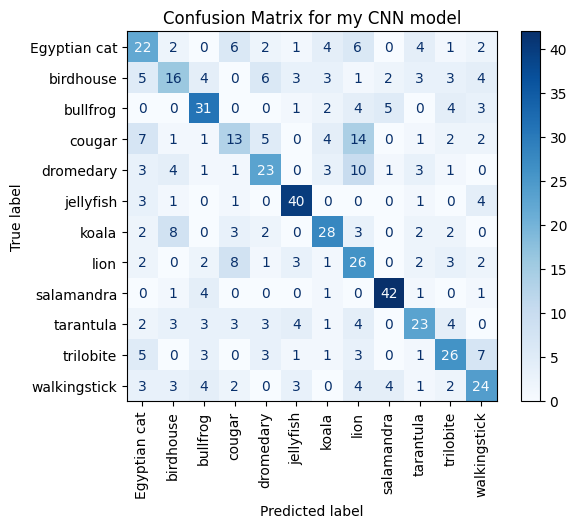

In [30]:
# Display the confusion matrix for CNN model
disp_confusion_matrix(y_test,y_pred_cnn,class_names,"Confusion Matrix for my CNN model")

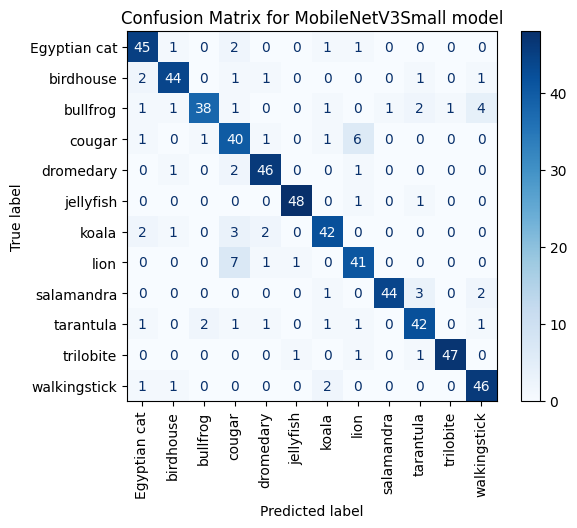

In [31]:
# Display the confusion matrix for MobileNetV3Small model
disp_confusion_matrix(y_test,y_pred_mobilenet,class_names,"Confusion Matrix for MobileNetV3Small model")

## 5.5 Comparing models by 20 images

* Summary of section 5.5:
  1. Obtain a lists of index that compare the ground truth value with the predicted values for both models.
  2. Use the display_images function and pass in the respective list of index to display the images.  

In [32]:
# The following code will compare the prediction values (both models) and truth values
# Those fulfill the logic requirement will extract the index of the respective

# Initialize list
both_true_idx = []
both_incorrect_idx = []
cnn_correct_only = []
mobilenet_correct_only = []

# Run a for loop to compare the ground truth value with prediction value of respective model
for i in range(len(y_test)):

  # Compare between CNN prediction and ground truth
  cnn_true = y_test[i] == y_pred_cnn[i]

  # Compare between pre-trained model prediction and ground truth
  mobilenet_true = y_test[i] == y_pred_mobilenet[i]

  # If CNN and pre-train model are both true, append the both_true_idx list
  if cnn_true == True and mobilenet_true == True:
    both_true_idx.append(i)

  # If CNN is True and pre-trained model is False, append cnn_correct_only list
  elif cnn_true == True and mobilenet_true == False:
    cnn_correct_only.append(i)

  # If CNN is False and pre-trained model is True, append mobilenet_correct_only list
  elif cnn_true == False and mobilenet_true == True:
    mobilenet_correct_only.append(i)

  # If CNN is False and pre-trained model is False, append both_incorrect_idx list
  elif cnn_true == False and mobilenet_true == False:
    both_incorrect_idx.append(i)


### Both models correctly classified images

In [33]:
# Total number that both models classify correctly
print(f"Number of images that both models correctly classified: {len(both_true_idx)}")

Number of images that both models correctly classified: 291


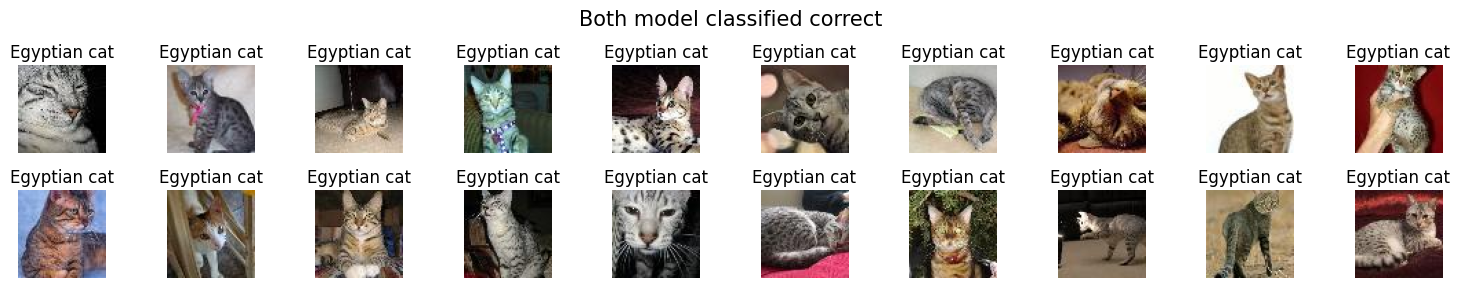

In [34]:
# Display the 20 images that both models classify correctly
display_images(X_test,y_test,class_names,num_images=20,plot_title="Both model classified correct",display_idx=both_true_idx)

### Both models incorrectly classified

In [35]:
# Total number that both model classify incorrectly
print(f"Number of images that both models incorrectly classified: {len(both_incorrect_idx)}")

Number of images that both models incorrectly classified: 54


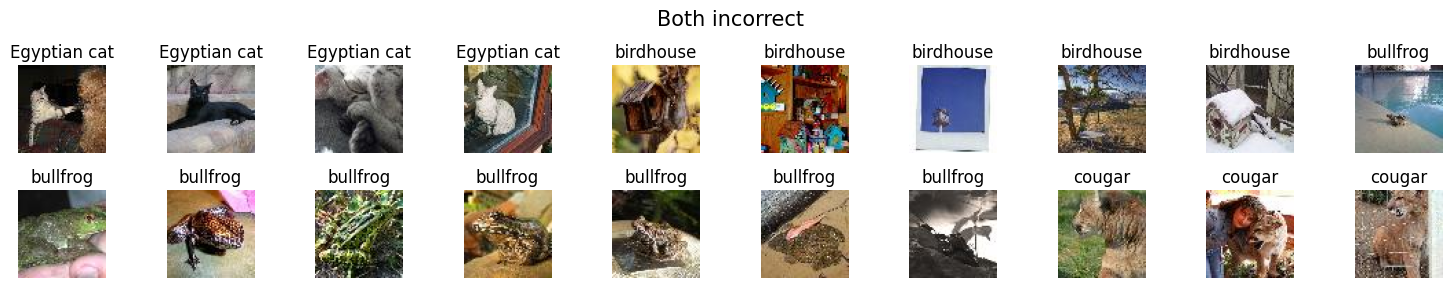

In [36]:
# Display the 20 images that both models classify incorrectly
display_images(X_test,y_test,class_names,num_images=20,plot_title="Both incorrect",display_idx=both_incorrect_idx)

### CNN classified correctly but retrained MobileNetV3Small classified incorrectly

In [37]:
# Total number that CNN classify correctly but MobileNetV3Small model did not
print(f"Number of images that CNN model classifies correctly only: {len(cnn_correct_only)}")

Number of images that CNN model classifies correctly only: 23


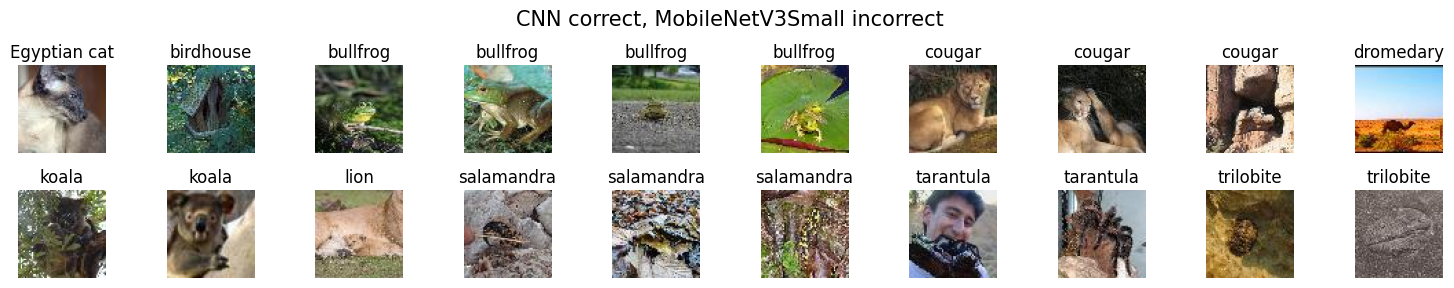

In [38]:
# Display the 20 images that CNN model classifies correctly only
display_images(X_test,y_test,class_names,num_images=20,plot_title="CNN correct, MobileNetV3Small incorrect",display_idx=cnn_correct_only)

### Retrained MobileNetV3Small classified correctly but CNN classified incorrectly

In [39]:
# Total number that pre-trained model classifies correctly only
print(f"Number of images that MobileNetV3Small model classifies correctly only: {len(mobilenet_correct_only)}")

Number of images that MobileNetV3Small model classifies correctly only: 232


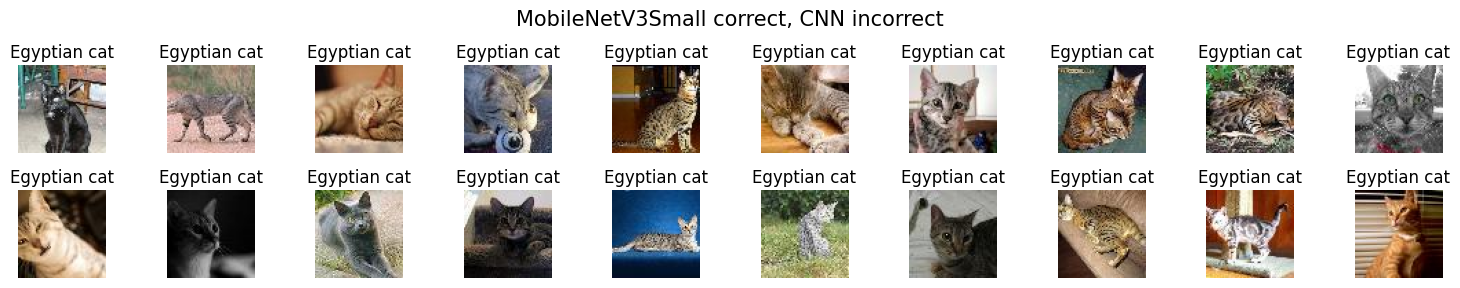

In [40]:
# Display the 20 images that MobileNetV3Small model classifies correctly only
display_images(X_test,y_test,class_names,num_images=20,plot_title="MobileNetV3Small correct, CNN incorrect",display_idx=mobilenet_correct_only)

## Section 5.6 Summary on both models and performance

* On hyperparameter tuning time and training time with respective the model's complexity
  * CNN model:
    * Total trainable parameter is 24,709
    * Time taken to tune the hyperparameter is approximate 5-6 minutes for each search
    * It took 4 searches to find the best model. Hence, total time taken is 22-23 minutes
  * MobileNetV3Small model:
    * Input layer is reshaped to (224,224,3) before pass to MobileNetV3Small model.
    * This will improve the accuracy from 60-65% to 85 - 88%. This is due to MobileNetV3Small model was trained by the image shape (224,224,3)
    * Total parameter is 956,802 but we freeze all layers except last 3 added layers. Hence, we reduce the trainable parameter
    * Total trainable parameter is 17,682 only
    * Time taken to train the model with implementation early stopping and exponential decay learning scheduler is approximate 1 minute
    * Learning curves shows the sign of overfitting. Further explanation and way to reduce overfitting can be found in the respective section. 

* On precision, recall, F1 and test accuracy
  * CNN model:
    * Accuracy: 52.3%
    * By comparison within classes, Cougar has lower precision, recall and F1 score which are 35.1%, 26.0% and 29.9% respectively.
    * While the class with highest precision, recall and F1 score is Salamandra which has 77.8%, 84% and 80.8% respectively
  * MobileNetV3Small model:
    * Accuracy: 87.2%
    * By comparison within classes, Cougar are the class with lowest precision, recall and F1 score which are 70.2%, 80.0% and 74.8%. 
    * Trilobite and jellyfish are among highest precision(97.9% and 96%) , recall (94% and 96%), and F1 score (95.9% and 96%).
  * Overall performance comparison between 2 models:
    * MobileNetV3Small model has higher accuracy, precison, recall and F1 score across all the classes compared to CNN model
    * Cougar is the class that has lower precision, recall and F1 score compared with other classes for both model


* On confusion matrix:
  * CNN model:
    * Cougar has only correctly identified 13 out of 50 images. 14 of them are wrongly classified as lion.
    * Lion has only correctly identified 26 out of 50 images. 8 of them are wrongly classified as Cougar.
    * Salamandra and jellyfish have correctly identified 42 and 40 out of 50 images.
  * MobileNetV3Small model:
    * Lion has only able to correctly identified 41 out of 50 images. 7 of them has been classified as Cougar.
    * Cougar has able to correctly identified 40 out of 50 images. 6 of them has been classified as lion.
    * The model has almost correctly identified for all the images of Jellyfish, Dromedary, Salamandra, Tribobite, and Walkingstick.
  * Overall comparison between 2 models:
    * Both models seem like have difficulty in identify between lion and cougar.
    * Both models are doing well in identifying Salamandra and Jellyfish

* On comparison models by comparing to the ground truth value:

|                   Description              | Total count |
| -----------------------------------------  | ----------- |
| Both model correctly classified            |     291     |
| Both model incorrectly classified          |      54     |
| CNN classified correctly only              |      23     |
| MobileNetV3Small classified correctly only |     232     |
|                     Total                  |     600     |


* Final comment on both model:

1. Hyperparameter tuning time for CNN model is higher than the training time for MobileNetV3Small model
2. The CNN model is more complex compared to MobileNetV3Small model as trainable parameter of CNN is more than MobileNetV3Small model.
3. Overall performance for MobileNetV3Small model is better than CNN model in terms of accuracy, precision, recall and F1 score.
4. However, from the learning curves of MobileNetV3Small, training accuracy is way higher than validation accuracy. The training loss is way lower than validation loss. This is the indication of overfitting issue. To reduce the overfitting issue, we can add in dropout layer before output layer. Batch normalization also can be added before the output layer. We can also set lower number of neurons in the dense layer before output layer. 
5. For MobileNetV3Small model, if the input remains as (64,64,3), the model accuracy is roughly around 60 - 65% only. However, if the input reshape to (224,224,3), the accuracy is improved to 85-88% range. This is due to the original MobileNetV3Small model is trained using the shape of (224,224,3).




